In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [5]:
df = pd.read_csv('height-weight.csv')

In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

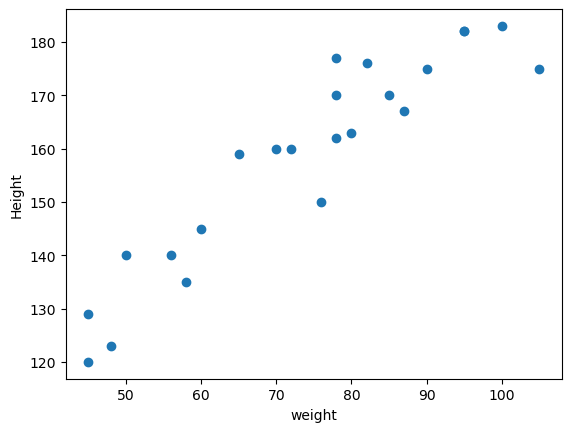

In [7]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("Height")      

In [8]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


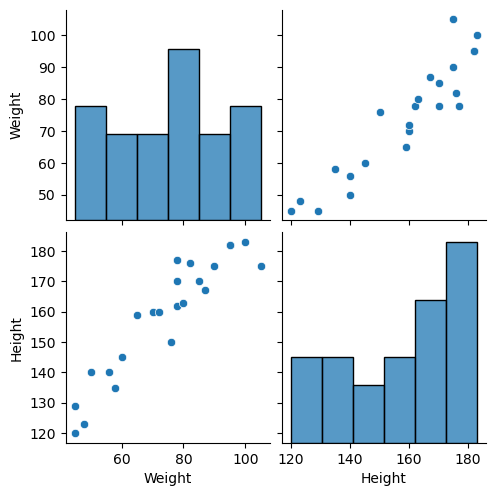

In [9]:
import seaborn as sns
sns.pairplot(df)

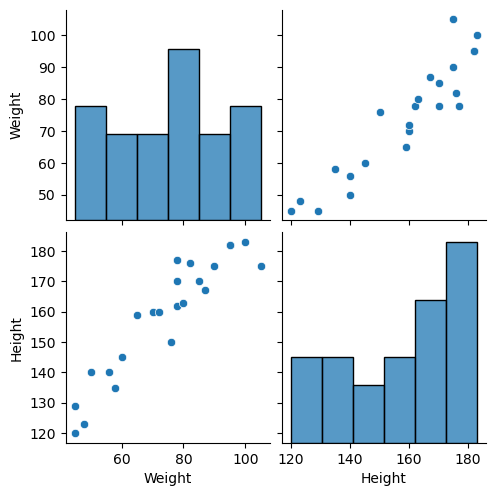

In [10]:
import seaborn as sns
sns.pairplot(df)

In [11]:
#independent and dependent
x = df[['Weight']]   #independent feature should be dataframe or 2d array.. use [['value']] to make it 2d or df
y = df['Height'] # dependent, can be 1D array or series  
type(x)

pandas.core.frame.DataFrame

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

In [14]:
x_test = scaler.transform(x_test) # why only transform because of dataleakage, the model should not know about test data ,so use only transform 


In [15]:
# now apply linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


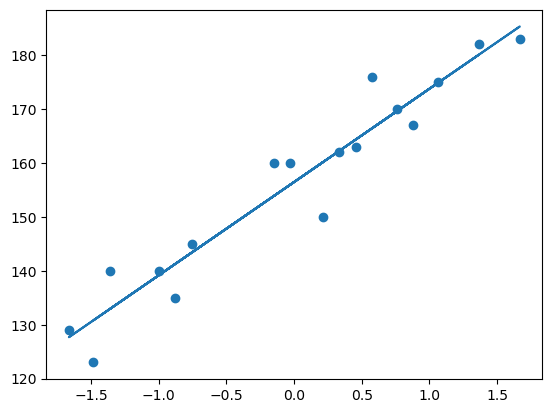

In [16]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [17]:
#prediction for test data
y_predict = regression.predict(x_test)
y_predict

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [18]:
#performance metrix
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse = mean_squared_error(y_test,y_predict)
mae = mean_absolute_error(y_test,y_predict)
rmse = np.sqrt(mse)

In [19]:
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


In [20]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_predict)

In [21]:
print(score)

0.7360826717981276


In [22]:
regression.predict(scaler.transform([[72]]))

c:\Users\poorn\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])

In [25]:
import pickle
with open("regression.pkl", "wb") as file:
    pickle.dump(regression, file)

In [26]:

model = pickle.load(open('regression.pkl','rb'))

In [27]:
model.predict(x_test)

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])